In [1]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
from sklearn.preprocessing import PowerTransformer

In [2]:
def get_lat_weights(latitude_values):
    lat_rad = np.deg2rad(latitude_values)
    weights = np.cos(lat_rad)
    return weights / np.mean(weights)

In [3]:
class Normalizer:
    def __init__(self):
        self.mean_in, self.std_in = None, None
        self.mean_out, self.std_out = None, None

    def set_input_statistics(self, mean, std):
        self.mean_in = mean
        self.std_in = std

    def set_output_statistics(self, mean, std):
        self.mean_out = mean
        self.std_out = std

    def normalize(self, data, data_type):
        if data_type == "input":
            return (data - self.mean_in) / self.std_in
        elif data_type == "output":
            return (data - self.mean_out) / self.std_out

    def inverse_transform_output(self, data):
        return data * self.std_out + self.mean_out

In [5]:
class PowerNormalizer:
    def __init__(self):
        self.pt_in = PowerTransformer(method='yeo-johnson') 
        self.pt_out = PowerTransformer(method='yeo-johnson') 

    def normalize(self, data, data_type):
        N, C, H, W = data.shape
        data_2d = data.reshape(data.shape[0], -1)
        if data_type == 'input':            
            return self.pt_in.fit_transform(data_2d).reshape(N, C, H, W)
        elif data_type == 'output':
            return self.pt_out.fit_transform(data_2d).reshape(N, C, H, W)

    def inverse_transform_output(self, data):
        N, C, H, W = data.shape
        data_2d = data.reshape(data.shape[0], -1)
        return self.pt_out.inverse_transform(data_2d).reshape(N, C, H, W)

In [6]:
class ClimateDataset(Dataset):
    def __init__(self, inputs_dask, outputs_dask, output_is_normalized=True):
        self.size = inputs_dask.shape[0]
        print(f"Creating dataset with {self.size} samples...")

        inputs_np = inputs_dask.compute()
        outputs_np = outputs_dask.compute()

        self.inputs = torch.from_numpy(inputs_np).float()
        self.outputs = torch.from_numpy(outputs_np).float()

        if torch.isnan(self.inputs).any() or torch.isnan(self.outputs).any():
            raise ValueError("NaNs found in dataset")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        return self.inputs[idx], self.outputs[idx]

In [7]:
path = "processed_data_cse151b_v2_corrupted_ssp245/processed_data_cse151b_v2_corrupted_ssp245.zarr"
input_vars = ["CO2", "SO2", "CH4", "BC", "rsdt"]
output_vars = ["tas", "pr"]
train_ssps = ["ssp126", "ssp370", "ssp585"]
test_ssp = "ssp245"
target_member_id = 0
val_split = 0.1
test_months = 360
batch_size = 32
num_workers = 0
seed = 42
normalizer = Normalizer()

In [8]:
ds = xr.open_zarr(path, consolidated=False, chunks={"time": 24})
spatial_template = ds["rsdt"].isel(time=0, ssp=0, drop=True)
lat = spatial_template.y.values
lon = spatial_template.x.values
area_weights = xr.DataArray(get_lat_weights(lat), dims=["y"], coords={"y": lat})

ds

<xarray.Dataset> Size: 621MB
Dimensions:    (ssp: 4, time: 1021, latitude: 48, longitude: 72, x: 72, y: 48,
                member_id: 3)
Coordinates:
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * member_id  (member_id) int64 24B 0 1 2
  * ssp        (ssp) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
Data variables:
    BC         (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CH4        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    CO2        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    pr         (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
    rsdt       (ssp, time, y, x) float32 56MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    SO2        (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    tas        (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
Attributes:
    original_member_ids:  ['r10i1p1f1', 'r11i1p1f1', 'r4i1p1f1']
    precipitation_units:  mm/day (converted from kg m-2 s-1)
    source:               CMIP6 data processed for CSE151B
    ssp:                  ssp126

In [9]:
def load_ssp(ssp):
    input_dask, output_dask = [], []
    for var in input_vars:
        da_var = ds[var].sel(ssp=ssp)
        if "latitude" in da_var.dims:
            da_var = da_var.rename({"latitude": "y", "longitude": "x"})
        if "member_id" in da_var.dims:
            da_var = da_var.sel(member_id=target_member_id)
        if set(da_var.dims) == {"time"}:
            da_var = da_var.broadcast_like(spatial_template).transpose("time", "y", "x")
        input_dask.append(da_var.data)

    for var in output_vars:
        da_out = ds[var].sel(ssp=ssp, member_id=target_member_id)
        if "latitude" in da_out.dims:
            da_out = da_out.rename({"latitude": "y", "longitude": "x"})
        output_dask.append(da_out.data)

    return da.stack(input_dask, axis=1), da.stack(output_dask, axis=1)

In [10]:
raw_train_inputs = []
raw_train_outputs = []

ssp_dc = {}

for ssp in train_ssps:
    x, y = load_ssp(ssp)

    if ssp == "ssp370":
        ssp_dc[ssp] = (x[:-test_months], y[:-test_months])
    else:
        ssp_dc[ssp] = (x, y)

    raw_train_inputs.append(ssp_dc[ssp][0])
    raw_train_outputs.append(ssp_dc[ssp][1])

raw_train_inputs = da.concatenate(raw_train_inputs, axis=0)
raw_train_outputs = da.concatenate(raw_train_outputs, axis=0)

normalizer.set_input_statistics(
    mean=da.nanmean(raw_train_inputs, axis=(0, 2, 3), keepdims=True).compute(),
    std=da.nanstd(raw_train_inputs, axis=(0, 2, 3), keepdims=True).compute(),
)
normalizer.set_output_statistics(
    mean=da.nanmean(raw_train_outputs, axis=(0, 2, 3), keepdims=True).compute(),
    std=da.nanstd(raw_train_outputs, axis=(0, 2, 3), keepdims=True).compute(),
)

In [11]:
pt_normalizer = PowerNormalizer()

In [12]:
train_input, train_output = [], []
val_input, val_output = [], []

def create_sequences(x, y, seq_len, pad_value=0.0):
    X_seq, Y_seq = [], []
    T = len(x)
    C, H, W = x.shape[1:]

    for t in range(T):
        start_idx = max(0, t - seq_len + 1)
        actual_seq = x[start_idx:t+1]

        padded_seq = np.full((seq_len, C, H, W), fill_value=pad_value, dtype=x.dtype)
        padded_seq[-(t - start_idx + 1):] = actual_seq

        X_seq.append(padded_seq)
        Y_seq.append(y[t])

    return X_seq, Y_seq

for ssp in train_ssps:
    x_train = normalizer.normalize(ssp_dc[ssp][0], 'input')
    y_train = pt_normalizer.normalize(ssp_dc[ssp][1], 'output')
    if ssp == "ssp370":
        x_val = normalizer.normalize(x[-test_months:], 'input')
        y_val = pt_normalizer.normalize(y[-test_months:], 'output')
        X_val, Y_val = create_sequences(x_val, y_val, seq_len=12)
        
        val_input.extend(X_val)
        val_output.extend(Y_val)
    
    X_seq, Y_seq = create_sequences(x_train, y_train, seq_len=12)
    train_input.extend(X_seq)
    train_output.extend(Y_seq)

len(train_input)

c:\Users\00011\anaconda3\envs\cse156\Lib\site-packages\dask\array\core.py:1739: FutureWarning: The `numpy.may_share_memory` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(
c:\Users\00011\anaconda3\envs\cse156\Lib\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\00011\anaconda3\envs\cse156\Lib\site-packages\numpy\_core\_methods.py:205: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
c:\Users\00011\anaconda3\envs\cse156\Lib\site-packages\dask\array\core.py:1739: FutureWarning: The `numpy.may_share_memory` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  w

KeyboardInterrupt: 

In [24]:
train_input = da.stack(train_input)
train_output = da.stack(train_output)

val_input = da.stack(val_input)
val_output = da.stack(val_output)

train_input.shape

(2703, 12, 5, 48, 72)

In [25]:
raw_test_input, raw_test_output = load_ssp(test_ssp)
raw_test_input = raw_test_input[-test_months:]
raw_test_output = raw_test_output[-test_months:]
x_test = normalizer.normalize(raw_test_input, "input")
X_test, Y_test = create_sequences(x_test, raw_test_output, seq_len=12)

test_input = da.stack(X_test)
test_output = da.stack(Y_test)

test_input.shape, test_output.shape

((360, 12, 5, 48, 72), (360, 2, 48, 72))

In [26]:
train_dataset = ClimateDataset(train_input, train_output)
val_dataset = ClimateDataset(val_input, val_output)
test_dataset = ClimateDataset(test_input, test_output, output_is_normalized=False)

Creating dataset with 2703 samples...
Creating dataset with 360 samples...
Creating dataset with 360 samples...


In [27]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

In [28]:
class CNNEncoder(nn.Module):
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            #nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            #nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 48 * 72, embed_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)  

In [29]:
class RNN(nn.Module):
    def __init__(self, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x_seq):
        out, _ = self.rnn(x_seq)
        out = out[:, -1]
        return self.fc(out)   

In [30]:
class Transformer(nn.Module):
    def __init__(self, embed_dim, hidden_dim, output_dim, num_heads=4, num_layers=2, dropout=0):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x_seq):
        out = self.transformer(x_seq)
        out = out[:, -1]     
        return self.fc(out)

In [31]:
class SpatiotemporalModel(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim, hidden_dim, H, W, temporal_model):
        super().__init__()
        self.encoder = CNNEncoder(in_channels, embed_dim)
        self.temporal = temporal_model(embed_dim, hidden_dim, out_channels * H * W)
        
        self.H = H
        self.W = W
        self.out_channels = out_channels
        self.in_channels = in_channels

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_seq = []
        for t in range(T):
            x_t = self.encoder(x[:, t])
            x_seq.append(x_t)
        x_seq = torch.stack(x_seq, dim=1)
        
        out = self.temporal(x_seq)
        
        return out.view(B, self.out_channels, H, W)

In [32]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Training on device {device}\n')

model = SpatiotemporalModel(in_channels=5, out_channels=2, embed_dim=128, hidden_dim=256, H=48, W=72, temporal_model=RNN).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(15):
    model.train()
    total_train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()

    with torch.no_grad():
        all_preds = []
        all_targets = []
        total_val_loss = 0
        
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)
            total_val_loss += loss.item()

            all_preds.append(pred.cpu())
            all_targets.append(yb.cpu())
        
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        all_preds = pt_normalizer.inverse_transform_output(all_preds.detach().cpu().numpy())
        all_targets = pt_normalizer.inverse_transform_output(all_targets.detach().cpu().numpy())
        
        time = np.arange(all_preds.shape[0])

        print(f"Epoch {epoch+1}: Train Loss = {total_train_loss / len(train_loader):.4f}, Valid Loss = {total_val_loss / len(val_loader):.4f}")  
    
        for i, var in enumerate(output_vars):
            p = all_preds[:, i]
            t = all_targets[:, i]
    
            p_xr = xr.DataArray(p, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
            t_xr = xr.DataArray(t, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
            
            rmse = np.sqrt(((p_xr - t_xr) ** 2).weighted(area_weights).mean(("time", "y", "x")).item())
            mean_rmse = np.sqrt(((p_xr.mean("time") - t_xr.mean("time")) ** 2).weighted(area_weights).mean(("y", "x")).item())
            std_mae = np.abs(p_xr.std("time") - t_xr.std("time")).weighted(area_weights).mean(("y", "x")).item()
    
            print(f"{var}: RMSE={rmse:.4f}, Time-Mean RMSE={mean_rmse:.4f}, Time-Stddev MAE={std_mae:.4f}")

    print('\n')
    

Training on device cuda

Epoch 1: Train Loss = 0.7309, Valid Loss = 0.5795
tas: RMSE=2.3274, Time-Mean RMSE=1.7230, Time-Stddev MAE=0.5231
pr: RMSE=2.1941, Time-Mean RMSE=0.5655, Time-Stddev MAE=1.0031


Epoch 2: Train Loss = 0.3706, Valid Loss = 0.5438
tas: RMSE=2.3228, Time-Mean RMSE=1.8037, Time-Stddev MAE=0.5253
pr: RMSE=2.2345, Time-Mean RMSE=0.4836, Time-Stddev MAE=0.9336


Epoch 3: Train Loss = 0.3612, Valid Loss = 0.5167
tas: RMSE=2.1377, Time-Mean RMSE=1.5785, Time-Stddev MAE=0.5868
pr: RMSE=2.0310, Time-Mean RMSE=0.4526, Time-Stddev MAE=0.9133


Epoch 4: Train Loss = 0.3564, Valid Loss = 0.5546
tas: RMSE=2.3638, Time-Mean RMSE=1.8865, Time-Stddev MAE=0.5846
pr: RMSE=76.7982, Time-Mean RMSE=4.2491, Time-Stddev MAE=2.5576


Epoch 5: Train Loss = 0.3541, Valid Loss = 0.5454
tas: RMSE=2.3141, Time-Mean RMSE=1.8421, Time-Stddev MAE=0.5183
pr: RMSE=2.0778, Time-Mean RMSE=0.4225, Time-Stddev MAE=0.8381


Epoch 6: Train Loss = 0.3526, Valid Loss = 0.5628
tas: RMSE=2.4312, Time-Mean R

KeyboardInterrupt: 

In [19]:
model.eval()

all_preds = []
all_targets = []

val_loss = 0

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        val_loss += loss.item()

        all_preds.append(pred.cpu())
        all_targets.append(yb.cpu())

print(f'Final Normalized Validation Loss: {val_loss / len(val_loader):.4f}')

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

all_preds = pt_normalizer.inverse_transform_output(all_preds.detach().cpu().numpy())
all_targets = pt_normalizer.inverse_transform_output(all_targets.detach().cpu().numpy())

for i, var in enumerate(output_vars):
    p = all_preds[:, i]
    t = all_targets[:, i]

    p_xr = xr.DataArray(p, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    t_xr = xr.DataArray(t, dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    
    rmse = np.sqrt(((p_xr - t_xr) ** 2).weighted(area_weights).mean(("time", "y", "x")).item())
    mean_rmse = np.sqrt(((p_xr.mean("time") - t_xr.mean("time")) ** 2).weighted(area_weights).mean(("y", "x")).item())
    std_mae = np.abs(p_xr.std("time") - t_xr.std("time")).weighted(area_weights).mean(("y", "x")).item()

    print(f"{var}: RMSE={rmse:.4f}, Time-Mean RMSE={mean_rmse:.4f}, Time-Stddev MAE={std_mae:.4f}")

Final Normalized Validation Loss: 0.1583
tas: RMSE=1.3731, Time-Mean RMSE=0.5518, Time-Stddev MAE=0.1994
pr: RMSE=1.9753, Time-Mean RMSE=0.1457, Time-Stddev MAE=0.7186


In [20]:
def plot_comparison(true_xr, pred_xr, title, cmap='viridis', diff_cmap='RdBu_r', metric=None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    vmin = min(true_xr.min().item(), pred_xr.min().item())
    vmax = max(true_xr.max().item(), pred_xr.max().item())

    # Ground truth
    true_xr.plot(ax=axs[0], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs[0].set_title(f"{title} (Ground Truth)")

    # Prediction
    pred_xr.plot(ax=axs[1], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=True)
    axs[1].set_title(f"{title} (Prediction)")

    # Difference
    diff = pred_xr - true_xr
    abs_max = np.max(np.abs(diff))
    diff.plot(ax=axs[2], cmap=diff_cmap, vmin=-abs_max, vmax=abs_max, add_colorbar=True)
    axs[2].set_title(f"{title} (Difference) {f'- {metric:.4f}' if metric else ''}")

    plt.tight_layout()
    plt.show()

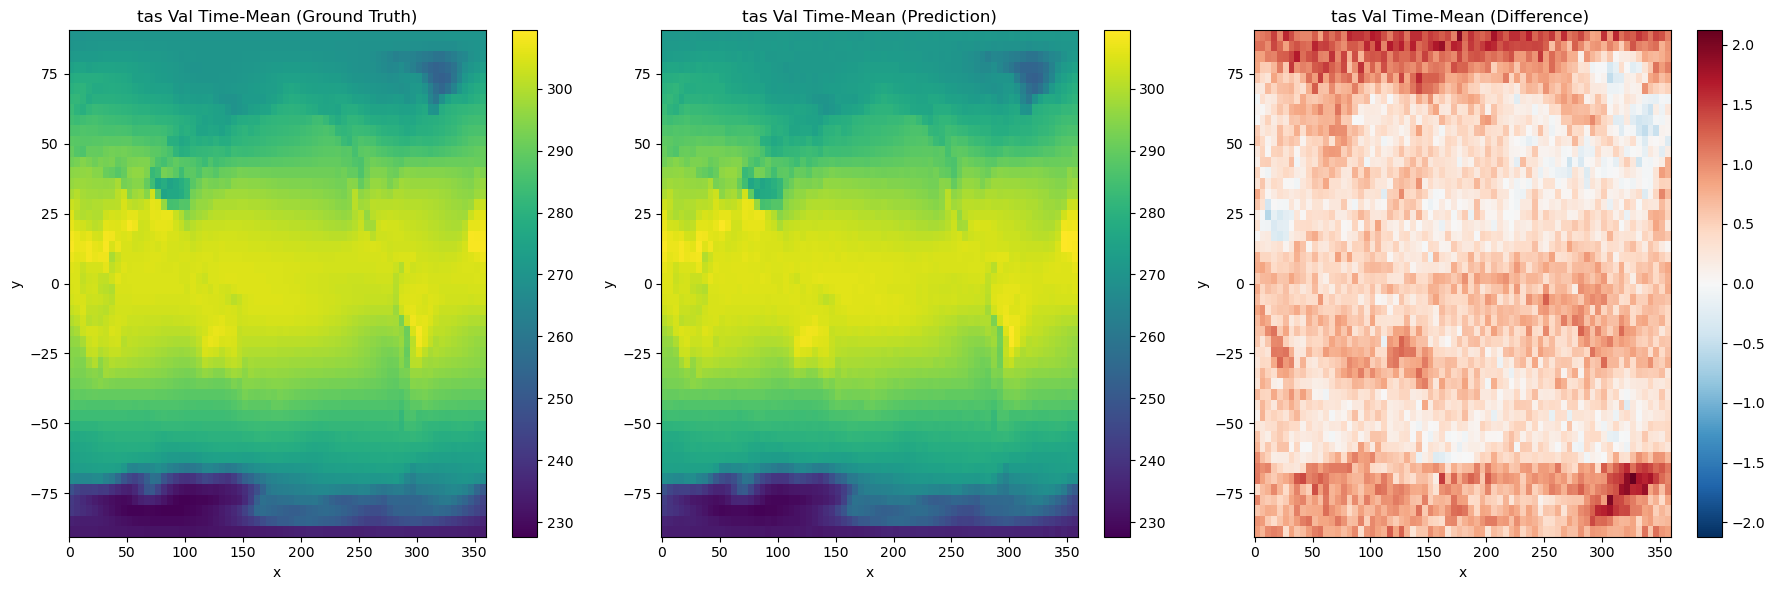

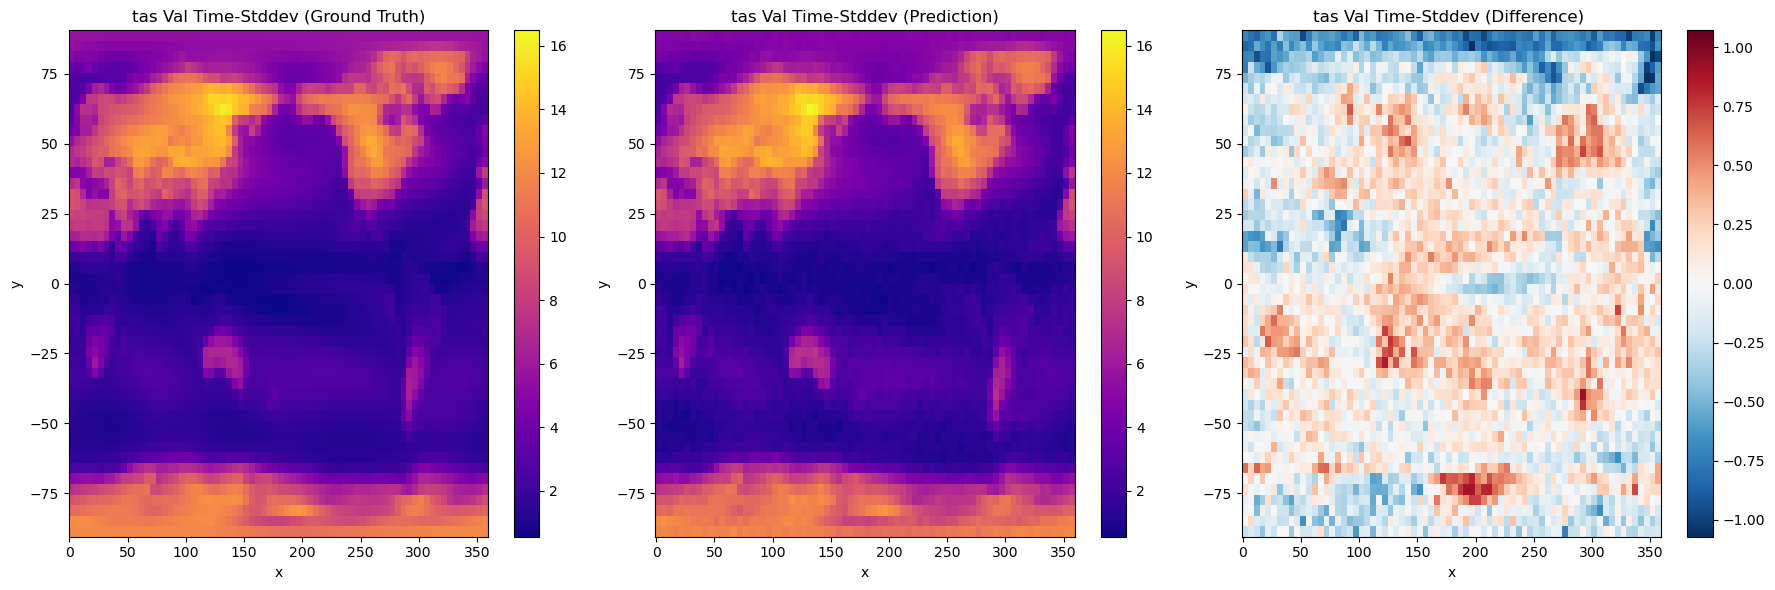

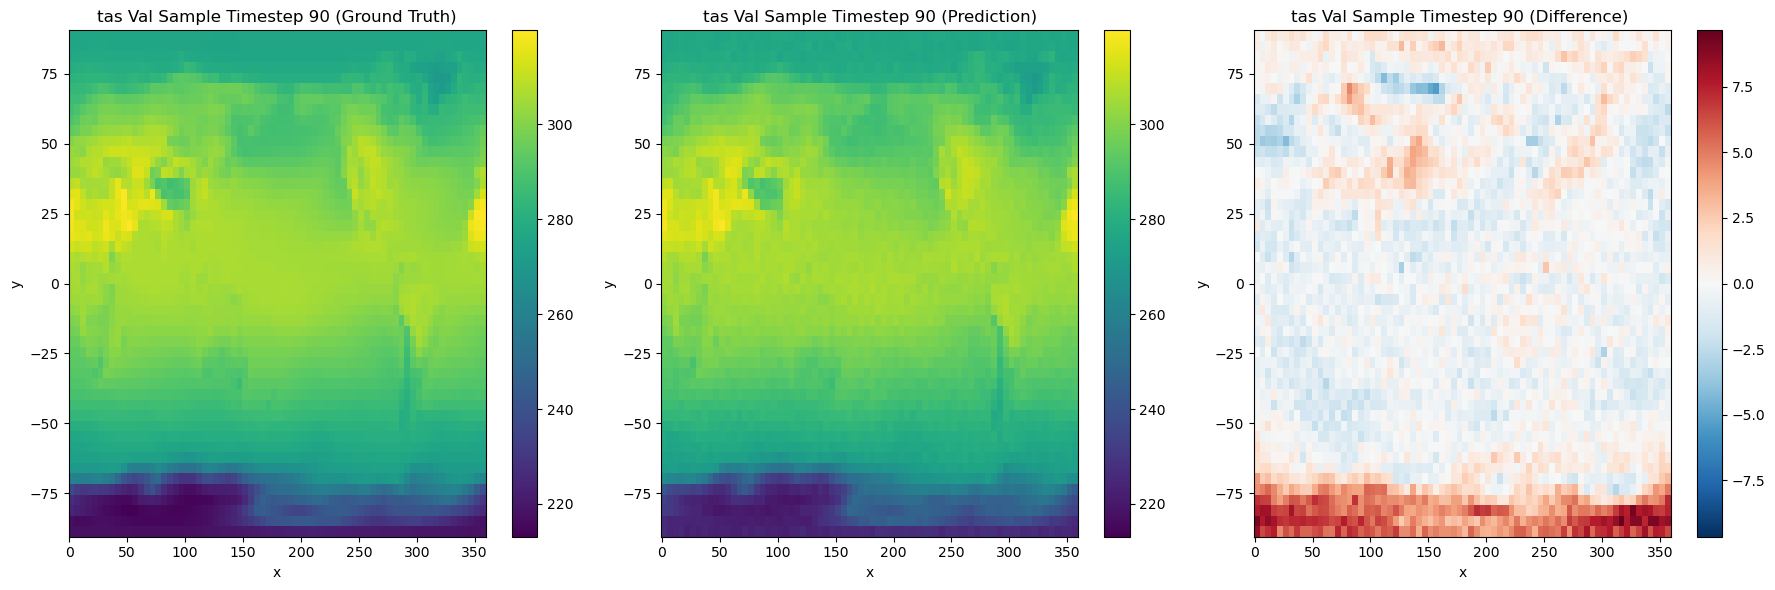

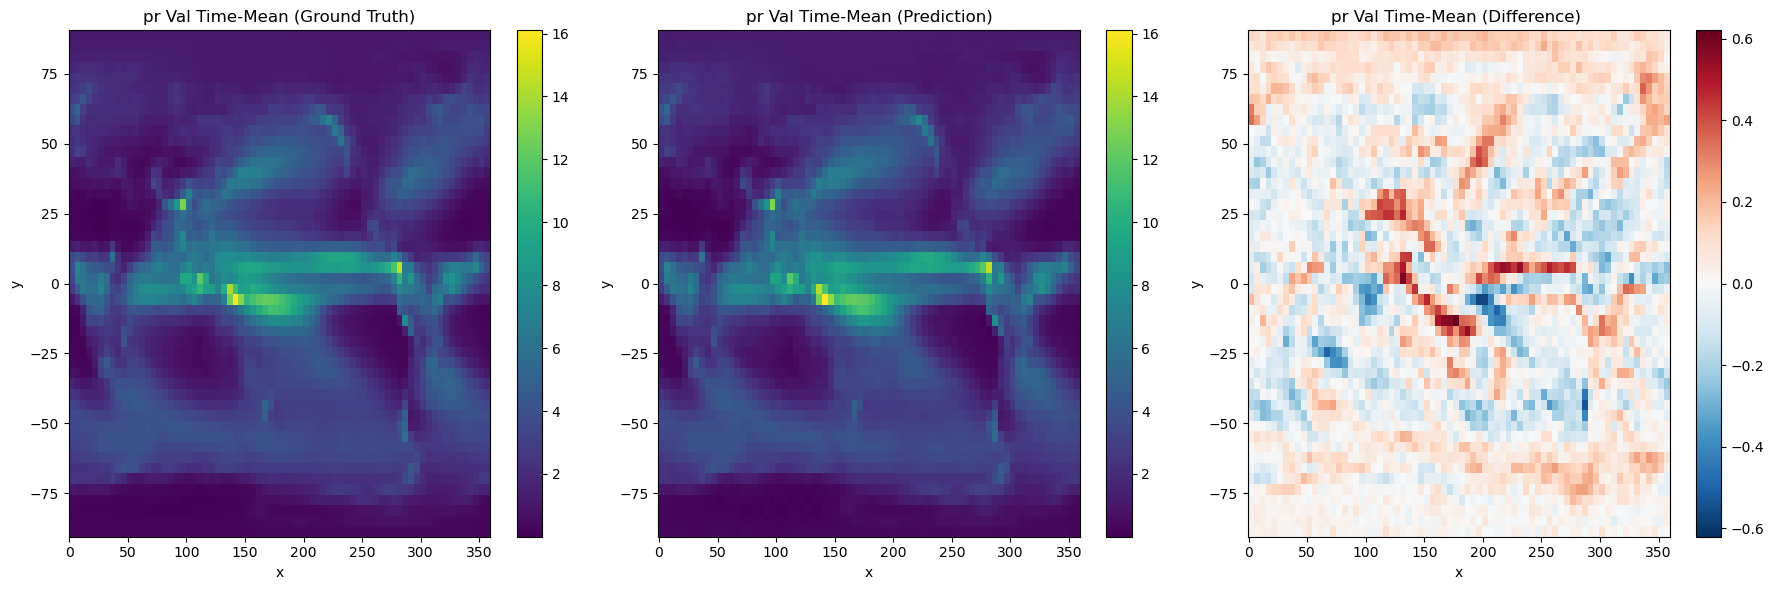

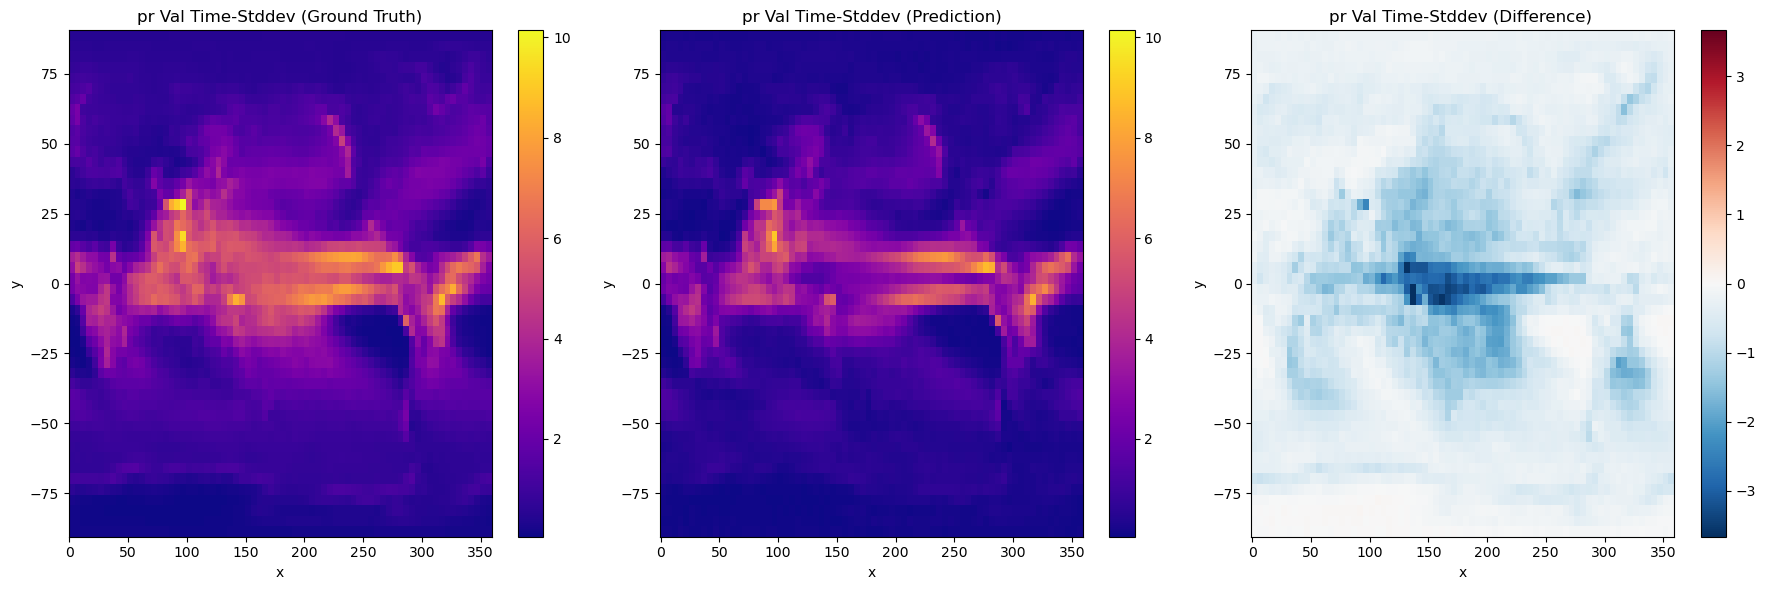

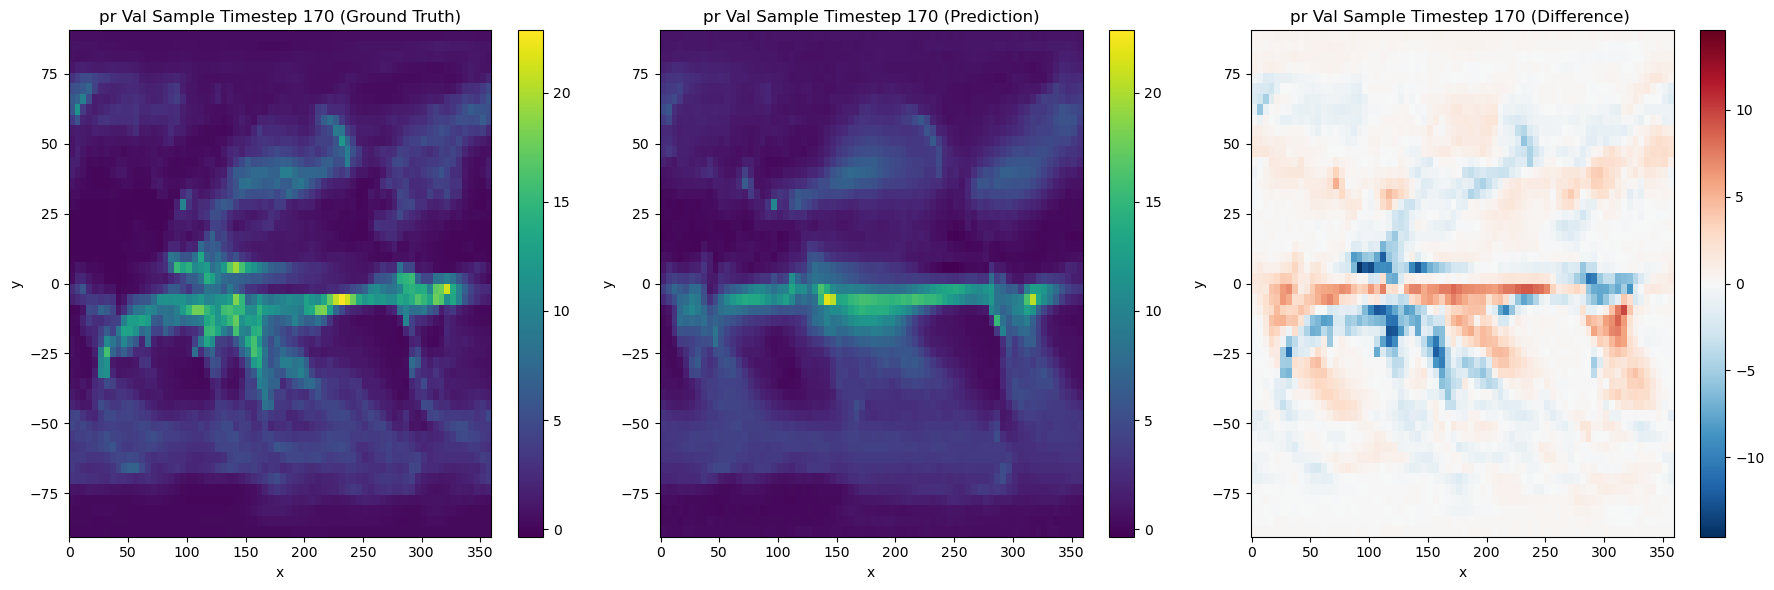

In [21]:
lat = spatial_template.y.values
lon = spatial_template.x.values
time = np.arange(all_preds.shape[0])

for i, var in enumerate(output_vars):
    pred_xr = xr.DataArray(all_preds[:, i], dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})
    true_xr = xr.DataArray(all_targets[:, i], dims=["time", "y", "x"], coords={"time": time, "y": lat, "x": lon})

    # --- Time Mean ---
    plot_comparison(true_xr.mean("time"), pred_xr.mean("time"), f"{var} Val Time-Mean")

    # --- Time Stddev ---
    plot_comparison(true_xr.std("time"), pred_xr.std("time"), f"{var} Val Time-Stddev", cmap="plasma")

    # --- Random timestep ---
    t_idx = np.random.randint(0, len(time))
    plot_comparison(true_xr.isel(time=t_idx), pred_xr.isel(time=t_idx), f"{var} Val Sample Timestep {t_idx}")

In [22]:
model.eval()

test_predictions = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_dataloader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred, yb)

        test_predictions.append(pred.cpu())
        test_targets.append(yb.cpu())

test_predictions = torch.cat(test_predictions, dim=0)
test_targets = torch.cat(test_targets, dim=0)

test_predictions = normalizer.inverse_transform_output(test_predictions.detach().cpu().numpy())
test_targets = normalizer.inverse_transform_output(test_targets.detach().cpu().numpy())

In [23]:
lat = spatial_template.y.values
lon = spatial_template.x.values
time = np.arange(test_predictions.shape[0])

rows = []
for t_idx, t in enumerate(time):
    for var_idx, var in enumerate(output_vars):
        for y_idx, y in enumerate(lat):
            for x_idx, x in enumerate(lon):
                row_id = f"t{t_idx:03d}_{var}_{y:.2f}_{x:.2f}"
                pred = test_predictions[t_idx, var_idx, y_idx, x_idx]
                rows.append({"ID": row_id, "Prediction": pred})

df = pd.DataFrame(rows)
os.makedirs("submissions", exist_ok=True)
filepath = f"submissions/kaggle_submission_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df.to_csv(filepath, index=False)
print(f"✅ Submission saved to: {filepath}")

✅ Submission saved to: submissions/kaggle_submission_20250520_202818.csv
